In [1]:
%pip install torch pandas numpy scikit-learn tqdm

In [12]:
!git clone https://github.com/imets01/synthetic_network_data_gen.git

Cloning into 'synthetic_network_data_gen'...
remote: Enumerating objects: 535, done.
remote: Counting objects: 100% (535/535), done.
remote: Compressing objects: 100% (272/272), done.
remote: Total 535 (delta 306), reused 467 (delta 256), pack-reused 0 (from 0)
Receiving objects: 100% (535/535), 6.26 MiB | 9.02 MiB/s, done.
Resolving deltas: 100% (306/306), done.


In [13]:
%cd synthetic_network_data_gen
!git fetch
!git checkout anna

/content/synthetic_network_data_gen
Branch 'anna' set up to track remote branch 'anna' from 'origin'.
Switched to a new branch 'anna'


In [4]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import zipfile

In [ ]:
class QuicSequenceDataset(Dataset):
    def __init__(self, high_level_csv, low_level_zip_path, folder_name_in_zip='quiche'):

        self.high_level_df = pd.read_csv(high_level_csv)
        self.high_level_df = self.high_level_df.head(20)
        self.low_level_zip_path = low_level_zip_path
        self.folder_name_in_zip = folder_name_in_zip

        to_keep = [
            'retry_occurred',
            'version_negotiation_occurred',
            'migration_type',  
            'handshake_duration',
            'time_to_migration',
            'migration_duration',
            'packets_before_migration',
            'total_bidi_streams_client_init',
            'total_udi_streams_client_init'
        ]
        self.condition_features_df = self.high_level_df[to_keep + ['file_id']]

        categorical_cols = self.condition_features_df.select_dtypes(include=['object', 'category']).columns
        self.condition_features_df = pd.get_dummies(self.condition_features_df, columns=categorical_cols, prefix=categorical_cols)

        self.flow_ids = self.high_level_df['file_id']
        condition_features_for_scaling = self.condition_features_df.drop('file_id', axis=1)

        self.condition_scaler = MinMaxScaler()
        self.sequence_scaler = MinMaxScaler()

        self.scaled_conditions = self.condition_scaler.fit_transform(condition_features_for_scaling)

        all_sequences = []
        self.sequence_columns = None

        with zipfile.ZipFile(self.low_level_zip_path, 'r') as zf:
            for flow_id in self.flow_ids:

                file_name_in_zip = f"{self.folder_name_in_zip}/quiche_capture_{flow_id}.csv"

                with zf.open(file_name_in_zip) as f:
                    df = pd.read_csv(f)
                    df = df.drop('frame_number', axis=1)

                    if self.sequence_columns is None:
                        self.sequence_columns = df.columns.tolist()
                    all_sequences.append(df.values)

        full_sequence_data = np.concatenate(all_sequences, axis=0)
        self.sequence_scaler.fit(full_sequence_data)

    def __len__(self):
        return len(self.high_level_df)

    def __getitem__(self, idx):
        flow_id = self.flow_ids.iloc[idx]

        file_name_in_zip = f"{self.folder_name_in_zip}/quiche_capture_{flow_id}.csv"

        with zipfile.ZipFile(self.low_level_zip_path, 'r') as zf:
            with zf.open(file_name_in_zip) as f:
                sequence_df = pd.read_csv(f)
                sequence_df = sequence_df.drop('frame_number', axis=1)

        scaled_sequence = self.sequence_scaler.transform(sequence_df.values)
        scaled_condition = self.scaled_conditions[idx]

        return {
            'sequence': torch.FloatTensor(scaled_sequence),
            'condition': torch.FloatTensor(scaled_condition)
        }

In [6]:
def collate_fn(batch):
    sequences = [item['sequence'] for item in batch]
    conditions = torch.stack([item['condition'] for item in batch])
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0.0)
    return {'sequence': padded_sequences, 'condition': conditions}

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim, sequence_feature_dim, hidden_dim=64, num_layers=1):
        super().__init__()

        self.rnn = nn.LSTM(input_size=condition_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

        self.fc_init_h = nn.Linear(latent_dim + condition_dim, hidden_dim * num_layers)
        self.fc_init_c = nn.Linear(latent_dim + condition_dim, hidden_dim * num_layers)

        self.fc_out = nn.Linear(hidden_dim, sequence_feature_dim)
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

    def forward(self, noise, condition, seq_len):
        batch_size = noise.shape[0]
        combined_input = torch.cat([noise, condition], dim=1)

        h0 = self.fc_init_h(combined_input).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_init_c(combined_input).view(self.num_layers, batch_size, self.hidden_dim)

        initial_state = (h0, c0)

        condition_expanded = condition.unsqueeze(1).repeat(1, seq_len, 1)

        rnn_out, _ = self.rnn(condition_expanded, initial_state)

        output = torch.sigmoid(self.fc_out(rnn_out)) 
        return output

class Discriminator(nn.Module):
    def __init__(self, condition_dim, sequence_feature_dim, hidden_dim=64, num_layers=1):
        super().__init__()

        self.rnn = nn.LSTM(input_size=sequence_feature_dim + condition_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, sequence, condition):
        seq_len = sequence.shape[1]
        condition_expanded = condition.unsqueeze(1).repeat(1, seq_len, 1)
        combined_input = torch.cat([sequence, condition_expanded], dim=2)

        _, (hn, cn) = self.rnn(combined_input)

        out = self.fc_out(hn[-1])

        return out


In [ ]:
def train_rgan(dataloader, generator, discriminator, g_optimizer, d_optimizer, loss_fn, device, epochs=100, latent_dim=10):
    for epoch in range(epochs):
        for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
            real_sequences = batch['sequence'].to(device)
            conditions = batch['condition'].to(device)
            batch_size, seq_len, _ = real_sequences.shape

            d_optimizer.zero_grad()
            real_output = discriminator(real_sequences, conditions)
            loss_real = loss_fn(real_output, torch.ones_like(real_output))

            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_sequences = generator(noise, conditions, seq_len)
            fake_output = discriminator(fake_sequences.detach(), conditions)
            loss_fake = loss_fn(fake_output, torch.zeros_like(fake_output))

            d_loss = (loss_real + loss_fake) / 2
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optimizer.step()

            g_optimizer.zero_grad()
            gen_output = discriminator(fake_sequences, conditions)
            g_loss = loss_fn(gen_output, torch.ones_like(gen_output))
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

In [9]:
DATA_DIR = "quic_data"
BATCH_SIZE = 64
LATENT_DIM = 20
HIDDEN_DIM = 256
EPOCHS = 2000
LR_G = 0.00005
LR_D = 0.000005

In [10]:
high_level_csv = '/content/synthetic_network_data_gen/test_gan_data/high_level_features.csv'
low_level_dir = '/content/synthetic_network_data_gen/test_gan_data/low_level_features/quiche.zip'

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = QuicSequenceDataset(high_level_csv, low_level_dir)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)


Using device: cuda


In [ ]:

condition_dim = dataset.scaled_conditions.shape[1]
sequence_feature_dim = dataset.sequence_scaler.n_features_in_

In [13]:
condition_dim, sequence_feature_dim

(9, 23)

In [ ]:
generator = Generator(LATENT_DIM, condition_dim, sequence_feature_dim, HIDDEN_DIM, 2).to(device)
discriminator = Discriminator(condition_dim, sequence_feature_dim, HIDDEN_DIM, 1).to(device)


In [ ]:
g_optimizer = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))
loss_fn = nn.BCEWithLogitsLoss()


train_rgan(dataloader, generator, discriminator, g_optimizer, d_optimizer, loss_fn, device, epochs=EPOCHS, latent_dim=LATENT_DIM)



Epoch 1/2000: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]


Epoch [1/2000], D Loss: 0.6879, G Loss: 0.6706


Epoch 2/2000: 100%|██████████| 1/1 [00:00<00:00,  3.13it/s]


Epoch [2/2000], D Loss: 0.6878, G Loss: 0.6709


Epoch 3/2000: 100%|██████████| 1/1 [00:00<00:00,  3.30it/s]


...

Epoch [1998/2000], D Loss: 0.6902, G Loss: 0.6893


Epoch 1999/2000: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]


Epoch [1999/2000], D Loss: 0.6900, G Loss: 0.6897


Epoch 2000/2000: 100%|██████████| 1/1 [00:00<00:00,  2.83it/s]

Epoch [2000/2000], D Loss: 0.6902, G Loss: 0.6894


In [ ]:
def post_process_generated_data(df, binary_cols, integer_cols):
    processed_df = df.copy()

    for col in binary_cols:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].clip(0, 1).round().astype(int)

    for col in integer_cols:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].clip(lower=0).round().astype(int)

    return processed_df

In [17]:
integer_cols = ['packet_length', 'count_initial', 'count_0rtt', 'count_handshake',
                'count_retry', 'count_vn', 'count_1rtt', 'count_ack', 'count_padding', 'count_connection_close',
                'count_path_challenge', 'count_path_response', 'count_new_connection_id',
                'count_retire_cid', 'count_crypto', 'count_handshake_done', 'http3_stream_count',
                'http3_fin_count', 'stream_length', 'stream_type_count']
binary_cols = ['packet_direction', 'header_form']

In [23]:
pd.set_option('display.max_columns', None)

In [24]:
print("\n--- Generating a new sample ---")

generator.eval()
with torch.no_grad():
    sample_condition_scaled = dataset[0]['condition'].unsqueeze(0).to(device)
    noise = torch.randn(1, LATENT_DIM, device=device)
    desired_seq_len = 25

    generated_sequence_scaled = generator(noise, sample_condition_scaled, desired_seq_len)

    generated_sequence_scaled_cpu = generated_sequence_scaled.squeeze(0).cpu().numpy()
    generated_sequence_original_scale = dataset.sequence_scaler.inverse_transform(generated_sequence_scaled_cpu)

    print("Generated sequence shape:", generated_sequence_original_scale.shape)
    og_scale = pd.DataFrame(generated_sequence_original_scale, columns=dataset.sequence_columns)
    print("Sample of generated data (original scale):\n")
    display(og_scale)
    print("Sample of generated data (processed scale):\n")
    display(post_process_generated_data(og_scale, binary_cols=binary_cols, integer_cols=integer_cols))


--- Generating a new sample ---
Generated sequence shape: (25, 23)
Sample of generated data (original scale):



,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count
0,0.014041,734.550781,0.474844,0.443458,0.465086,0.492540,0.445421,0.538818,0.470711,0.448196,1.086426,0.470966,0.476692,0.441094,0.450643,0.519867,0.462025,0.999212,0.434357,0.485572,0.473287,98.025520,0.483346
1,0.012961,692.376709,0.430137,0.395701,0.396603,0.412278,0.380149,0.564641,0.398972,0.376320,1.011203,0.418672,0.446830,0.390755,0.411065,0.438827,0.407018,0.817442,0.376517,0.460073,0.451239,92.514412,0.473418
2,0.011753,627.507507,0.362123,0.315790,0.317684,0.309485,0.291118,0.596069,0.305064,0.281936,0.953195,0.341881,0.413605,0.320521,0.349459,0.339373,0.330914,0.603255,0.288828,0.410142,0.391678,75.707642,0.437198
3,0.010118,541.354919,0.265062,0.212588,0.214483,0.189516,0.181252,0.644209,0.189806,0.169315,0.890348,0.242758,0.360368,0.230393,0.265575,0.223967,0.229717,0.357882,0.178649,0.340343,0.300010,51.445114,0.380915
4,0.008000,436.848755,0.153799,0.110312,0.110242,0.083542,0.082602,0.715983,0.085581,0.073167,0.817077,0.140114,0.277967,0.137762,0.173705,0.114246,0.124814,0.151829,0.079821,0.252761,0.187442,25.670603,0.303254
5,0.005840,338.554382,0.068402,0.045656,0.043859,0.027206,0.029305,0.804909,0.028960,0.024447,0.749107,0.069744,0.175701,0.073975,0.104065,0.046496,0.055178,0.049397,0.027065,0.168984,0.091284,8.903613,0.219143
6,0.004380,279.458282,0.027724,0.021100,0.018361,0.009567,0.012002,0.881427,0.010744,0.009594,0.728101,0.041497,0.091691,0.048761,0.073662,0.021058,0.026866,0.018843,0.010196,0.113668,0.039533,2.669063,0.156642
7,0.003775,260.995941,0.013183,0.014952,0.011019,0.005375,0.007852,0.923706,0.006381,0.006306,0.764261,0.038003,0.048001,0.047767,0.072245,0.014536,0.018467,0.011977,0.005969,0.082982,0.019056,0.985879,0.121345
8,0.003656,261.937988,0.008138,0.014712,0.009162,0.004600,0.007335,0.939666,0.005695,0.006179,0.812158,0.045638,0.031039,0.057303,0.083698,0.014075,0.016510,0.011365,0.004990,0.063628,0.011267,0.520546,0.099893
9,0.003710,266.678375,0.006305,0.015914,0.008824,0.004676,0.007727,0.943949,0.005962,0.006885,0.845554,0.055809,0.024819,0.067551,0.095712,0.015204,0.016288,0.012410,0.004820,0.051858,0.008171,0.373239,0.085875


Sample of generated data (processed scale):



,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count
0,0.014041,735,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,98,0
1,0.012961,692,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,93,0
2,0.011753,628,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,76,0
3,0.010118,541,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,51,0
4,0.008000,437,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,26,0
5,0.005840,339,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,9,0
6,0.004380,279,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,3,0
7,0.003775,261,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
8,0.003656,262,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
9,0.003710,267,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
sample_condition = dataset[0]['condition']

In [ ]:
dataset[0]['sequence']

tensor([[0.0000e+00, 0.0000e+00, 8.5704e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [4.3478e-02, 5.0271e-02, 2.9630e-03, 1.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [8.6957e-02, 2.0533e-01, 8.5704e-01, 0.0000e+00, 1.0000e+00, 1.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         5.0000e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.3043e-01, 2.31

In [ ]:
dataset.flow_ids

,file_id
0,1
1,10
2,11
3,12
4,13
5,14
6,15
7,16
8,17
9,18


In [ ]:
sample_condition

tensor([0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3993, 0.5000, 0.4897, 0.5000, 0.5000, 0.5000, 0.0000, 1.0000, 1.0000,
        0.5484, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])

In [ ]:
dataset.sequence_scaler.inverse_transform(sample_condition.squeeze(0).cpu().numpy())

ValueError: Expected 2D array, got 1D array instead:
array=[0.         1.         0.         0.         0.         0.
 0.         0.         0.         0.3992893  0.5        0.48965517
 0.5        0.5        0.5        0.         1.         1.
 0.54841703 1.         1.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.5        0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

## WGAN

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import zipfile
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import torch.autograd as autograd

CRITIC_ITERATIONS = 5  
LAMBDA_GP = 10         

class QuicSequenceDataset(Dataset):
    def __init__(self, high_level_csv, low_level_zip_path, folder_name_in_zip='quiche'):

        self.high_level_df = pd.read_csv(high_level_csv)
        self.high_level_df = self.high_level_df.head(20)
        self.low_level_zip_path = low_level_zip_path
        self.folder_name_in_zip = folder_name_in_zip

        to_keep = [
            'retry_occurred', 'version_negotiation_occurred', 'migration_type',
            'handshake_duration', 'time_to_migration', 'migration_duration',
            'packets_before_migration', 'total_bidi_streams_client_init',
            'total_udi_streams_client_init',
            'path_validation_initiated', 
            # 'connection_close_type' 
        ]
        self.condition_features_df = self.high_level_df 

        for col in to_keep:
            if col not in self.condition_features_df.columns:
                 self.condition_features_df[col] = 0 

        self.condition_features_df = self.condition_features_df[to_keep + ['file_id']]

        categorical_cols = self.condition_features_df.select_dtypes(include=['object', 'category']).columns
        if 'migration_type' in self.condition_features_df.columns:
            self.condition_features_df['migration_type'] = self.condition_features_df['migration_type'].astype('category')
            categorical_cols = self.condition_features_df.select_dtypes(include=['category']).columns
        self.condition_features_df = pd.get_dummies(self.condition_features_df, columns=categorical_cols, prefix=categorical_cols)

        self.flow_ids = self.high_level_df['file_id']
        condition_features_for_scaling = self.condition_features_df.drop('file_id', axis=1)

        self.condition_scaler = MinMaxScaler(feature_range=(-1, 1))
        self.sequence_scaler = MinMaxScaler(feature_range=(-1, 1))

        self.scaled_conditions = self.condition_scaler.fit_transform(condition_features_for_scaling)

        all_sequences = []
        self.sequence_columns = None
        with zipfile.ZipFile(self.low_level_zip_path, 'r') as zf:
            for flow_id in self.flow_ids:
                file_name_in_zip = f"{self.folder_name_in_zip}/quiche_capture_{flow_id}.csv"
                with zf.open(file_name_in_zip) as f:
                    df = pd.read_csv(f).drop('frame_number', axis=1)
                    if self.sequence_columns is None: self.sequence_columns = df.columns.tolist()
                    all_sequences.append(df.values)
        full_sequence_data = np.concatenate(all_sequences, axis=0)
        self.sequence_scaler.fit(full_sequence_data)

    def __len__(self):
        return len(self.high_level_df)

    def __getitem__(self, idx):
        flow_id = self.flow_ids.iloc[idx]
        file_name_in_zip = f"{self.folder_name_in_zip}/quiche_capture_{flow_id}.csv"
        with zipfile.ZipFile(self.low_level_zip_path, 'r') as zf:
            with zf.open(file_name_in_zip) as f:
                sequence_df = pd.read_csv(f).drop('frame_number', axis=1)
        scaled_sequence = self.sequence_scaler.transform(sequence_df.values)
        scaled_condition = self.scaled_conditions[idx]
        return {'sequence': torch.FloatTensor(scaled_sequence), 'condition': torch.FloatTensor(scaled_condition)}

def collate_fn(batch):
    sequences = [item['sequence'] for item in batch]
    conditions = torch.stack([item['condition'] for item in batch])
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0.0)
    return {'sequence': padded_sequences, 'condition': conditions}

class Generator(nn.Module):
    def __init__(self, latent_dim, condition_dim, sequence_feature_dim, hidden_dim=64, num_layers=1):
        super().__init__()
        self.rnn = nn.LSTM(input_size=condition_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_init_h = nn.Linear(latent_dim + condition_dim, hidden_dim * num_layers)
        self.fc_init_c = nn.Linear(latent_dim + condition_dim, hidden_dim * num_layers)
        self.fc_out = nn.Linear(hidden_dim, sequence_feature_dim)
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

    def forward(self, noise, condition, seq_len):
        batch_size = noise.shape[0]
        combined_input = torch.cat([noise, condition], dim=1)
        h0 = self.fc_init_h(combined_input).view(self.num_layers, batch_size, self.hidden_dim)
        c0 = self.fc_init_c(combined_input).view(self.num_layers, batch_size, self.hidden_dim)
        initial_state = (h0, c0)
        condition_expanded = condition.unsqueeze(1).repeat(1, seq_len, 1)
        rnn_out, _ = self.rnn(condition_expanded, initial_state)

        output = torch.tanh(self.fc_out(rnn_out))
        return output
    
class Critic(nn.Module):
    def __init__(self, condition_dim, sequence_feature_dim, hidden_dim=64, num_layers=1):
        super().__init__()
        self.rnn = nn.LSTM(input_size=sequence_feature_dim + condition_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, sequence, condition):
        seq_len = sequence.shape[1]
        condition_expanded = condition.unsqueeze(1).repeat(1, seq_len, 1)
        combined_input = torch.cat([sequence, condition_expanded], dim=2)
        _, (hn, cn) = self.rnn(combined_input)
        out = self.fc_out(hn[-1])

        return out

def compute_gradient_penalty(critic, real_samples, fake_samples, condition, device):
    alpha = torch.randn(real_samples.size(0), 1, 1, device=device)

    alpha = alpha.expand_as(real_samples)

    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)

    with torch.backends.cudnn.flags(enabled=False):
        d_interpolates = critic(interpolates, condition)

    fake = torch.ones(d_interpolates.size(), device=device)

    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.reshape(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

def train_wgan_gp(dataloader, generator, critic, g_optimizer, d_optimizer, device, epochs=100, latent_dim=10):
    for epoch in range(epochs):
        for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
            real_sequences = batch['sequence'].to(device)
            conditions = batch['condition'].to(device)
            batch_size, seq_len, _ = real_sequences.shape

            for _ in range(CRITIC_ITERATIONS):
                d_optimizer.zero_grad()
                noise = torch.randn(batch_size, latent_dim, device=device)
                fake_sequences = generator(noise, conditions, seq_len)

                real_validity = critic(real_sequences, conditions)
                fake_validity = critic(fake_sequences.detach(), conditions)

                gradient_penalty = compute_gradient_penalty(critic, real_sequences.data, fake_sequences.data, conditions.data, device)

                d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + LAMBDA_GP * gradient_penalty
                d_loss.backward()
                d_optimizer.step()

            g_optimizer.zero_grad()
            gen_sequences = generator(noise, conditions, seq_len)
            g_loss = -torch.mean(critic(gen_sequences, conditions))
            g_loss.backward()
            g_optimizer.step()

        print(f"Epoch [{epoch+1}/{epochs}], Critic Loss: {d_loss.item():.4f}, Generator Loss: {g_loss.item():.4f}")



In [ ]:
DATA_DIR = "quic_data"
BATCH_SIZE = 64
LATENT_DIM = 20
HIDDEN_DIM = 256
EPOCHS = 5000 
LR = 0.0001 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = QuicSequenceDataset(high_level_csv, low_level_zip_path=low_level_dir) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

condition_dim = dataset.scaled_conditions.shape[1]
sequence_feature_dim = len(dataset.sequence_columns)

generator = Generator(LATENT_DIM, condition_dim, sequence_feature_dim, HIDDEN_DIM, num_layers=2).to(device)
critic = Critic(condition_dim, sequence_feature_dim, HIDDEN_DIM, num_layers=1).to(device)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(critic.parameters(), lr=LR, betas=(0.5, 0.999))

train_wgan_gp(dataloader, generator, critic, g_optimizer, d_optimizer, device, epochs=EPOCHS, latent_dim=LATENT_DIM)

In [ ]:
import pandas as pd
import numpy as np
import torch

def post_process_generated_data(generated_sequences_tensor,
                                high_level_conditions_tensor,
                                sequence_scaler,
                                condition_scaler,
                                sequence_columns,
                                condition_columns_after_dummies):
    """
    Takes raw GAN output and transforms it into clean, consistent, and protocol-correct data.

    This function handles:
    1. Inverse scaling to real-world values.
    2. Rounding binary flags and handling one-hot encoded features.
    3. Enforcing deterministic rules (e.g., creating frame_number).
    4. Reconciling high-level summary stats to match the generated low-level data.
    """

    generated_sequences_np = generated_sequences_tensor.squeeze(0).cpu().detach().numpy()
    high_level_conditions_np = high_level_conditions_tensor.cpu().detach().numpy()


    unscaled_sequences = sequence_scaler.inverse_transform(generated_sequences_np)
    unscaled_conditions = condition_scaler.inverse_transform(high_level_conditions_np)

    low_level_df = pd.DataFrame(unscaled_sequences, columns=sequence_columns)
    high_level_df = pd.DataFrame(unscaled_conditions, columns=condition_columns_after_dummies)

    for col in [c for c in low_level_df.columns if c.startswith(('has_', 'is_', 'retry_occurred', 'version_negotiation_occurred'))]:
        low_level_df[col] = low_level_df[col].round().astype(int)

    low_level_df.insert(0, 'frame_number', np.arange(1, len(low_level_df) + 1))

    if 'packet_direction' in low_level_df.columns and 'packet_length' in low_level_df.columns:
        packets_sent_client = len(low_level_df[low_level_df['packet_direction'] == 0])
        packets_sent_server = len(low_level_df[low_level_df['packet_direction'] == 1])
        bytes_sent_client = low_level_df.loc[low_level_df['packet_direction'] == 0, 'packet_length'].sum()
        bytes_sent_server = low_level_df.loc[low_level_df['packet_direction'] == 1, 'packet_length'].sum()

        if 'quic_packets_sent_client' in high_level_df.columns:
            high_level_df['quic_packets_sent_client'] = packets_sent_client
        if 'quic_packets_sent_server' in high_level_df.columns:
             high_level_df['quic_packets_sent_server'] = packets_sent_server

    return low_level_df, high_level_df


In [ ]:
print("\n--- Generating and Refining a New Sample ---")

generator.eval()

with torch.no_grad():
    sample_condition_scaled = dataset[0]['condition'].unsqueeze(0).to(device)

    noise = torch.randn(1, LATENT_DIM, device=device)

    desired_seq_len = 27
    generated_sequence_scaled = generator(noise, sample_condition_scaled, desired_seq_len)
    final_low_level_df, final_high_level_df = post_process_generated_data(
        generated_sequences_tensor=generated_sequence_scaled,
        high_level_conditions_tensor=sample_condition_scaled,
        sequence_scaler=dataset.sequence_scaler,
        condition_scaler=dataset.condition_scaler,
        sequence_columns=dataset.sequence_columns,
        condition_columns_after_dummies=dataset.condition_scaler.get_feature_names_out()
    )
    print("\n--- Final, Cleaned Synthetic Data ---")

    print("\nReconciled High-Level Features:")
    display(final_high_level_df)

    print("\nGenerated Low-Level Packet Sequence:")
    display(final_low_level_df)


--- Generating and Refining a New Sample ---

--- Final, Cleaned Synthetic Data ---

Reconciled High-Level Features:


,retry_occurred,version_negotiation_occurred,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init,path_validation_initiated,migration_type_IP_AND_PORT
0,1.0,1.0,9.505033,11.000156,0.862837,13.0,1.0,4.0,1.0,1.0



Generated Low-Level Packet Sequence:


,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count
0,1,0.000210,1218.943115,0.000827,0.001457,0.005195,0.001565,9.804964e-06,0.999693,0.000092,0.002712,0.010431,9.160459e-03,0.015544,1.057988e-02,1.013845e-03,0.000163,0.001070,0.004171,1.304150e-04,1.044339e-02,6.109774e-04,1.038955,1.592934e-02
1,2,0.000299,77.694595,0.995166,0.007677,0.002359,0.000882,9.775162e-06,0.990571,0.007546,0.960991,0.045759,1.651049e-05,0.006176,2.570152e-04,6.340146e-04,0.000001,0.000943,0.009471,3.129244e-06,7.082522e-04,4.112720e-04,2.168925,1.247942e-03
2,3,0.000760,1309.266724,0.005848,0.976415,0.987347,0.005966,6.616116e-05,0.016888,0.010108,0.016067,0.000926,6.191105e-03,0.005863,6.249487e-03,8.173198e-03,0.000011,0.003812,0.941093,8.940697e-07,1.010299e-04,4.893541e-05,0.035205,1.048744e-04
3,4,0.000695,98.980812,0.992734,0.996403,0.019938,0.004631,1.063019e-03,0.000545,0.979653,0.010560,0.014682,8.592010e-05,0.002658,4.327595e-04,1.636028e-03,0.000003,0.002674,0.046811,1.072884e-06,1.228720e-03,8.231968e-03,2.086890,3.687441e-04
4,5,0.000661,1277.331909,0.011314,0.999541,0.990243,0.004348,1.826987e-02,0.000393,0.010524,0.000581,0.015376,4.220575e-03,0.003475,6.501377e-04,2.253056e-03,0.000028,0.001588,1.047185,1.132488e-06,1.264215e-04,1.743138e-04,0.048297,6.321073e-05
5,6,0.002079,1287.113403,0.987246,0.999903,0.965401,0.007731,9.816595e-01,0.000330,0.005646,0.002453,0.859198,9.403527e-03,0.001019,1.219958e-03,1.221627e-02,0.001178,0.002928,1.951180,4.214048e-05,1.264811e-04,1.043648e-03,1.158032,7.736683e-05
6,7,0.000544,492.716827,0.982033,0.998907,0.028974,0.002508,9.988560e-01,0.019064,0.000203,0.000116,0.091659,2.105141e-02,0.000517,3.596842e-04,1.989365e-03,0.008417,0.001221,0.959143,9.775162e-05,2.116561e-04,1.308322e-04,0.423439,3.507137e-04
7,8,0.003194,1371.192627,0.015648,0.975961,0.986200,0.003622,9.856213e-01,0.989812,0.000027,0.000034,1.933332,9.854845e-01,0.000170,5.178094e-03,4.560888e-03,0.996147,0.003289,1.064116,1.677933e-02,9.437621e-03,9.629130e-05,1.208783,8.325398e-03
8,9,0.001153,554.502930,0.986944,0.010982,0.009947,0.001403,8.227915e-03,0.999962,0.000022,0.000044,0.849054,1.037171e-02,0.000104,2.172589e-04,1.427531e-05,0.979585,0.000381,1.205453,9.771628e-01,9.918792e-01,1.221120e-03,26.158876,9.902704e-01
9,10,0.000137,75.947266,0.983626,0.000436,0.000013,0.000105,6.860495e-05,0.999992,0.000007,0.000006,0.009133,7.539988e-06,0.000055,2.026558e-06,5.960464e-08,0.013899,0.000011,0.019340,1.811719e-02,9.990466e-01,1.142025e-03,1.883352,9.987071e-01


In [32]:
%pip install joblib

In [34]:
import os
import joblib

In [ ]:
save_dir = "content/trained_wgan_quic"
os.makedirs(save_dir, exist_ok=True)
generator_path = os.path.join(save_dir, "generator.pth")
critic_path = os.path.join(save_dir, "critic.pth")
sequence_scaler_path = os.path.join(save_dir, "sequence_scaler.gz")
condition_scaler_path = os.path.join(save_dir, "condition_scaler.gz")
sequence_columns_path = os.path.join(save_dir, "sequence_columns.json")

torch.save(generator.state_dict(), generator_path)
torch.save(critic.state_dict(), critic_path)

joblib.dump(dataset.sequence_scaler, sequence_scaler_path)
joblib.dump(dataset.condition_scaler, condition_scaler_path)

import json
with open(sequence_columns_path, 'w') as f:
    json.dump(dataset.sequence_columns, f)

print(f"Models saved to {generator_path} and {critic_path}")
print(f"Scalers saved to {sequence_scaler_path} and {condition_scaler_path}")
print(f"Columns saved to {sequence_columns_path}")

Models saved to content/trained_wgan_quic/generator.pth and content/trained_wgan_quic/critic.pth
Scalers saved to content/trained_wgan_quic/sequence_scaler.gz and content/trained_wgan_quic/condition_scaler.gz
Columns saved to content/trained_wgan_quic/sequence_columns.json


## Loading model with GPU

In [ ]:
import torch
import joblib
import json
import os
import pandas as pd
import numpy as np

print("--- Loading pre-trained models and scalers for synthesis ---")

load_dir = ""
generator_path = os.path.join(load_dir, "generator.pth")
critic_path = os.path.join(load_dir, "critic.pth")
sequence_scaler_path = os.path.join(load_dir, "sequence_scaler.gz")
condition_scaler_path = os.path.join(load_dir, "condition_scaler.gz")
sequence_columns_path = os.path.join(load_dir, "sequence_columns.json")

LATENT_DIM = 20
HIDDEN_DIM = 256
NUM_LAYERS_GEN = 2
NUM_LAYERS_CRITIC = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sequence_scaler = joblib.load(sequence_scaler_path)
condition_scaler = joblib.load(condition_scaler_path)

with open(sequence_columns_path, 'r') as f:
    sequence_columns = json.load(f)

sequence_feature_dim = sequence_scaler.n_features_in_
condition_dim = condition_scaler.n_features_in_

loaded_generator = Generator(LATENT_DIM, condition_dim, sequence_feature_dim, HIDDEN_DIM, num_layers=NUM_LAYERS_GEN).to(device)

loaded_generator.load_state_dict(torch.load(generator_path))

print("Generator loaded successfully.")



print("\n--- Generating and Refining a New Sample ---")
loaded_generator.eval()
with torch.no_grad():
    sample_condition_scaled = torch.FloatTensor(dataset.scaled_conditions[0]).unsqueeze(0).to(device)

    noise = torch.randn(1, LATENT_DIM, device=device)
    desired_seq_len = 50

    generated_sequence_scaled = loaded_generator(noise, sample_condition_scaled, desired_seq_len)

    final_low_level_df, final_high_level_df = post_process_generated_data(
        generated_sequences_tensor=generated_sequence_scaled,
        high_level_conditions_tensor=sample_condition_scaled,
        sequence_scaler=sequence_scaler,
        condition_scaler=condition_scaler,
        sequence_columns=sequence_columns,
        condition_columns_after_dummies=condition_scaler.get_feature_names_out()
    )

    print("\n--- Final, Cleaned Synthetic Data ---")
    print("\nReconciled High-Level Features:")
    display(final_high_level_df)
    print("\nGenerated Low-Level Packet Sequence:")
    display(final_low_level_df)

--- Loading pre-trained models and scalers for synthesis ---


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
## Loading model with CPU

In [ ]:
import torch
import joblib
import json
import os
import pandas as pd
import numpy as np

print("--- Loading pre-trained models and scalers for synthesis ---")

load_dir = "/content/"
generator_path = os.path.join(load_dir, "generator.pth")
sequence_scaler_path = os.path.join(load_dir, "sequence_scaler.gz")
condition_scaler_path = os.path.join(load_dir, "condition_scaler.gz")
sequence_columns_path = os.path.join(load_dir, "sequence_columns.json")

LATENT_DIM = 20
HIDDEN_DIM = 256
NUM_LAYERS_GEN = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sequence_scaler = joblib.load(sequence_scaler_path)
condition_scaler = joblib.load(condition_scaler_path)

with open(sequence_columns_path, 'r') as f:
    sequence_columns = json.load(f)

sequence_feature_dim = sequence_scaler.n_features_in_
condition_dim = condition_scaler.n_features_in_

loaded_generator = Generator(LATENT_DIM, condition_dim, sequence_feature_dim, HIDDEN_DIM, num_layers=NUM_LAYERS_GEN)

loaded_generator.load_state_dict(torch.load(generator_path, map_location=device))

loaded_generator.to(device)

print("Generator loaded successfully.")


print("\n--- Generating and Refining a New Sample ---")
loaded_generator.eval()
with torch.no_grad():

    dataset = QuicSequenceDataset(high_level_csv, low_level_dir)
    data = [
      1.0,        # retry occurred
      1.0,        # version negotiation occurred
      8.380674,   # handshake_duration
      10.277851,  # time_to_migration
      0.8774,     # migration_duration
      13.0,       # packets_before_migration
      1.0,        # total_bidi_streams_client_init
      4.0,        # total_udi_streams_client_init
      1.0,        # path_validation_initiated
      1.0         # migration_type_IP_AND_PORT
    ]

    tensor = np.array(data, dtype=float)

    tensor = tensor.reshape(1, -1)
    sample_condition_scaled = torch.FloatTensor(condition_scaler.transform(tensor)).to(device)

    noise = torch.randn(1, LATENT_DIM, device=device)
    desired_seq_len = 13

    generated_sequence_scaled = loaded_generator(noise, sample_condition_scaled, desired_seq_len)

    final_low_level_df, final_high_level_df = post_process_generated_data(
        generated_sequences_tensor=generated_sequence_scaled,
        high_level_conditions_tensor=sample_condition_scaled,
        sequence_scaler=sequence_scaler,
        condition_scaler=condition_scaler,
        sequence_columns=sequence_columns,
        condition_columns_after_dummies=condition_scaler.get_feature_names_out()
    )

    print("\n--- Final, Cleaned Synthetic Data ---")
    print("\nReconciled High-Level Features:")
    display(final_high_level_df)
    print("\nGenerated Low-Level Packet Sequence:")
    display(final_low_level_df)

--- Loading pre-trained models and scalers for synthesis ---
Using device: cpu
Generator loaded successfully.

--- Generating and Refining a New Sample ---

--- Final, Cleaned Synthetic Data ---

Reconciled High-Level Features:


/tmp/ipython-input-1170549695.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.condition_features_df['migration_type'] = self.condition_features_df['migration_type'].astype('category')
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,retry_occurred,version_negotiation_occurred,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init,path_validation_initiated,migration_type_IP_AND_PORT
0,1.0,1.0,8.380674,10.277851,0.8774,13.0,1.0,4.0,1.0,1.0



Generated Low-Level Packet Sequence:


,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count
0,1,0.000175,1227.100342,0.001187,0.001700,0.004649,0.001105,0.000009,0.999663,0.000086,0.003297,0.009382,0.012248,0.015812,0.012243,9.121299e-04,9.730458e-05,0.001032,0.003176,1.100302e-04,0.006432,0.000379,0.993811,0.009823
1,2,0.000299,77.679642,0.994862,0.008707,0.002456,0.000896,0.000010,0.986492,0.008322,0.965663,0.036809,0.000018,0.006362,0.000269,6.331205e-04,9.834766e-07,0.001020,0.010871,3.069639e-06,0.000662,0.000296,1.881528,0.001137
2,3,0.000779,1310.363525,0.005992,0.977730,0.986802,0.006133,0.000068,0.013520,0.010877,0.016209,0.000847,0.006146,0.005718,0.006741,8.642137e-03,1.069903e-05,0.003940,0.975544,9.536743e-07,0.000099,0.000044,0.033190,0.000108
3,4,0.000687,98.019638,0.993059,0.996365,0.018140,0.004536,0.001037,0.000538,0.979838,0.010183,0.014630,0.000083,0.002573,0.000437,1.651436e-03,3.039837e-06,0.002630,0.045403,1.043081e-06,0.001170,0.008198,2.069781,0.000368
4,5,0.000646,1281.466309,0.011052,0.999546,0.990003,0.004328,0.017877,0.000407,0.010218,0.000558,0.015132,0.004300,0.003528,0.000675,2.355039e-03,2.726912e-05,0.001530,1.032187,1.102686e-06,0.000121,0.000164,0.046947,0.000062
5,6,0.002090,1290.316650,0.987194,0.999902,0.965096,0.007674,0.981267,0.000332,0.005703,0.002400,0.868666,0.009479,0.001032,0.001281,1.266757e-02,1.158208e-03,0.002846,1.951172,4.157424e-05,0.000124,0.001033,1.139011,0.000077
6,7,0.000528,494.502472,0.981477,0.998901,0.027365,0.002496,0.998852,0.018572,0.000206,0.000112,0.085833,0.021022,0.000516,0.000374,2.127588e-03,8.277565e-03,0.001186,0.948436,9.971857e-05,0.000207,0.000129,0.375533,0.000348
7,8,0.003162,1371.584106,0.014729,0.976774,0.986428,0.003550,0.986281,0.989446,0.000027,0.000034,1.935834,0.986348,0.000169,0.005299,5.027920e-03,9.962767e-01,0.003213,1.056907,1.696441e-02,0.008854,0.000093,1.130717,0.007862
8,9,0.001184,571.315918,0.987181,0.011333,0.010646,0.001423,0.008786,0.999960,0.000022,0.000046,0.885924,0.011312,0.000108,0.000231,1.540780e-05,9.807581e-01,0.000394,1.220839,9.781963e-01,0.991384,0.001215,26.792448,0.989740
9,10,0.000138,75.990738,0.983760,0.000446,0.000014,0.000106,0.000071,0.999992,0.000007,0.000006,0.009331,0.000008,0.000056,0.000002,5.960464e-08,1.451579e-02,0.000011,0.019957,1.904771e-02,0.999026,0.001108,1.891502,0.998680


In [17]:
pd.set_option('display.max_column', None)

array([-1.        , -1.        ,  0.6204433 ,  0.38056368, -0.91671082,
       -1.        , -1.        , -1.        , -1.        , -1.        ])

In [19]:
sample_condition_scaled

tensor([[-1.0000, -1.0000,  0.6204,  0.3806, -0.9167, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000]])

## Trying out PARSynthetizer from SDV

In [ ]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.3/193.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.3/198.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 9.6 MB/s eta 0:00:00


In [ ]:
from sdv.sequential import PARSynthesizer
from sdv.metadata import Metadata

In [ ]:
data = pd.read_csv("/content/synthetic_network_data_gen/test_gan_data/low_level_features/merged_captures_1_3080.csv")

In [ ]:
metadata = Metadata.detect_from_dataframe(data)

In [ ]:
def update_metadata(metadata, cols, correct_metadata, computer_representation = None):
  for i in range(len(cols)):
    metadata.update_column(
      column_name=cols[i],
      sdtype=correct_metadata,
    )
    if computer_representation is not None:
      metadata.update_column(
        column_name=cols[i],
        computer_representation=computer_representation,
      )
  return metadata

In [ ]:
metadata = update_metadata(metadata, binary_cols, 'boolean')
metadata = update_metadata(metadata, integer_cols, 'numerical', 'Int64')


In [ ]:
metadata.set_sequence_key('capture_id')

In [ ]:
metadata.set_sequence_index('frame_number')

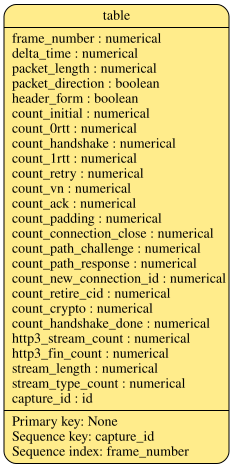

In [ ]:
metadata.visualize()

In [ ]:
data[binary_cols] = data[binary_cols].astype(bool)

In [ ]:
from sdv.sequential import PARSynthesizer

synthesizer = PARSynthesizer(metadata, verbose=True)
synthesizer.fit(data)

synthetic_data = synthesizer.sample(num_sequences=100)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
synthetic_data

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000439,795,False,True,0,0,0,1,0,...,0,0,0,0,0,0,0,15,0,3159657
1,2,-0.000010,860,True,True,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,3159657
2,3,0.000566,119,True,False,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,3159657
3,4,0.001087,408,False,True,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3159657
4,5,0.001295,75,True,False,0,0,0,1,0,...,0,0,0,1,0,0,0,6,0,3159657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2685,23,0.000578,84,False,False,0,0,0,1,0,...,0,0,0,0,0,1,1,16,1,5492773
2686,24,-0.000010,351,False,False,0,0,0,1,0,...,0,0,0,0,0,0,0,62,0,5492773
2687,25,0.000856,75,True,False,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,5492773
2688,26,-0.000010,75,False,False,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,5492773


In [ ]:
output_path = '/content/drive/My Drive/MAP/my_final_dataframe.csv'

synthetic_data.to_csv(output_path, index=False)

print(f"✅ DataFrame successfully saved to: {output_path}")

✅ DataFrame successfully saved to: /content/drive/My Drive/MAP/my_final_dataframe.csv


In [ ]:
synthetic_data[synthetic_data['capture_id'] == 10283550]

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
81,1,0.000154,810,True,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51,0,10283550
82,2,0.000183,75,False,True,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,10283550
83,3,-0.000010,1068,False,True,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10283550
84,4,-0.000010,517,True,False,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,3,0,10283550
85,5,0.001179,1049,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,10283550
86,6,0.000923,75,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10283550
87,7,-0.000010,198,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,2,0,10283550
88,8,-0.000010,75,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,1,10283550
89,9,-0.000010,300,False,False,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,25,1,10283550
90,10,0.000619,422,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,10283550


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
display(synthetic_data)

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000439,795,False,True,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,15,0,3159657
1,2,-0.000010,860,True,True,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3159657
2,3,0.000566,119,True,False,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,3159657
3,4,0.001087,408,False,True,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3159657
4,5,0.001295,75,True,False,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,6,0,3159657
5,6,0.001658,805,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,3159657
6,7,0.000883,857,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3159657
7,8,0.000386,333,True,False,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3159657
8,9,0.001356,75,False,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3159657
9,10,0.000714,806,True,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,4,1,3159657
